## LSTM Model Experiment Univariat

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import MinMaxScaler  

np.random.seed(10122097)

In [2]:
train = pd.read_csv('../datasets/train.csv', parse_dates=['date']).drop(columns='id')
transactions = pd.read_csv('../datasets/transactions.csv', parse_dates=['date'])
df_full_stats = pd.read_csv('descriptive_stats_all_combinations.csv')
stores = pd.read_csv('../datasets/stores.csv')

### Melakukan Pemilihan Data Yang Akan Digunakan 

In [3]:
smooth_combinations = df_full_stats[df_full_stats['category']=='Smooth'][['store_nbr','family']]
print(f"Jumlah kombinasi Smooth: {len(smooth_combinations)}")  # cek apakah benar ~630

TIME_STEPS = 14
pooled_X, pooled_y, pooled_meta, series_scalers = [], [], [], {}

for _, row in smooth_combinations.iterrows():
    store, family = row['store_nbr'], row['family']
    df_sub = train[(train['store_nbr']==store) & (train['family']==family)]
    df_sub = df_sub.groupby('date')['sales'].sum().reset_index().set_index('date').asfreq('D').fillna(0)
    sales = df_sub['sales'].values
    if len(sales) < TIME_STEPS + 20:
        continue

    # PENTING: scaling per-series (bukan global), agar toko besar tidak mendominasi
    scaler = MinMaxScaler()
    sales_scaled = scaler.fit_transform(sales.reshape(-1,1)).flatten()
    series_scalers[(store, family)] = scaler  # simpan untuk inverse transform nanti

    for i in range(len(sales_scaled) - TIME_STEPS):
        pooled_X.append(sales_scaled[i:i+TIME_STEPS])
        pooled_y.append(sales_scaled[i+TIME_STEPS])
        pooled_meta.append((store, family, i))

pooled_X = np.array(pooled_X).reshape(-1, TIME_STEPS, 1)
pooled_y = np.array(pooled_y)
print(f"Total sequences hasil pooling: {len(pooled_X)}")

Jumlah kombinasi Smooth: 630
Total sequences hasil pooling: 1054620


In [4]:
train_idx, test_idx = [], []
for (store, family) in smooth_combinations.itertuples(index=False):
    idxs = [i for i, m in enumerate(pooled_meta) if m[0]==store and m[1]==family]
    split = int(len(idxs) * 0.8)
    train_idx += idxs[:split]
    test_idx += idxs[split:]

X_train_pooled, y_train_pooled = pooled_X[train_idx], pooled_y[train_idx]
X_test_pooled, y_test_pooled = pooled_X[test_idx], pooled_y[test_idx]
print(f"Train: {len(X_train_pooled)} | Test: {len(X_test_pooled)}")

Train: 843570 | Test: 211050


## LSTM Univariat

### Eksperimen Model LSTM Univariat Dengan Model LSTM Sederhana

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_log_error

In [6]:
# Membangun Arsitektur LSTM Sederhana (1 Layer)
model = Sequential([
    Input(shape=(TIME_STEPS, 1)),
    LSTM(64, activation='tanh', dropout=0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Pelatihan Model Global
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Memulai pelatihan model global untuk 630 kombinasi 'Smooth'...")
history = model.fit(
    X_train_pooled, y_train_pooled,
    validation_split=0.1, # 10% data train untuk validasi
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Memulai pelatihan model global untuk 630 kombinasi 'Smooth'...
Epoch 1/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 83s 25ms/step - loss: 0.0153 - val_loss: 0.0166
Epoch 2/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 122s 41ms/step - loss: 0.0134 - val_loss: 0.0146
Epoch 3/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 95s 32ms/step - loss: 0.0131 - val_loss: 0.0122
Epoch 4/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 179s 60ms/step - loss: 0.0129 - val_loss: 0.0127
Epoch 5/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step - loss: 0.0127 - val_loss: 0.0115
Epoch 6/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 110s 18ms/step - loss: 0.0126 - val_loss: 0.0133
Epoch 7/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 0.0126 - val_loss: 0.0136
Epoch 8/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 0.0125 - val_loss: 0.0130


### Evaluasi dan Visualisasi Hasil Prediksi (6 Kombinasi Target)


In [8]:
# Evaluasi pada tiap kombinasi secara individu
results = []
plot_data_uv = {}
print("Mulai proses evaluasi per kombinasi...")

# Ubah test_idx menjadi set untuk mempercepat pencarian (O(1))
test_idx_set = set(test_idx)

for idx, (store, family) in enumerate(smooth_combinations.itertuples(index=False)):
    # Ambil index data test untuk kombinasi ini
    combo_test_idxs = [i for i, m in enumerate(pooled_meta) if m[0]==store and m[1]==family and i in test_idx_set]
    
    if len(combo_test_idxs) == 0:
        continue
        
    X_test_combo = pooled_X[combo_test_idxs]   
    y_test_combo_scaled = pooled_y[combo_test_idxs]
    
    # Lakukan prediksi
    y_pred_scaled = model.predict(X_test_combo, verbose=0)
    
    # Inverse transform
    scaler = series_scalers[(store, family)]
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_combo = scaler.inverse_transform(y_test_combo_scaled.reshape(-1, 1))
    
    # Hitung metrik
    # Hitung metrik RMSLE (Pastikan tidak ada nilai negatif sebelum di log)
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))

    
    results.append({
        'store_nbr': store,
        'family': family,
        'RMSLE': rmsle

    })
    plot_data_uv[(store, family)] = (y_test_combo, y_pred)
    
    if (idx + 1) % 50 == 0:
        print(f"Selesai evaluasi {idx + 1} kombinasi...")

results_df = pd.DataFrame(results)
print("\n--- Rangkuman Evaluasi Keseluruhan ---")
display(results_df[['RMSLE']].describe())

Mulai proses evaluasi per kombinasi...
Selesai evaluasi 50 kombinasi...
Selesai evaluasi 100 kombinasi...
Selesai evaluasi 150 kombinasi...
Selesai evaluasi 200 kombinasi...
Selesai evaluasi 250 kombinasi...
Selesai evaluasi 300 kombinasi...
Selesai evaluasi 350 kombinasi...
Selesai evaluasi 400 kombinasi...
Selesai evaluasi 450 kombinasi...
Selesai evaluasi 500 kombinasi...
Selesai evaluasi 550 kombinasi...
Selesai evaluasi 600 kombinasi...

--- Rangkuman Evaluasi Keseluruhan ---


,RMSLE
count,630.000000
mean,0.624407
std,0.392511
min,0.394478
25%,0.492667
50%,0.541516
75%,0.619362
max,4.030782


Hasil Evaluasi untuk 6 Kombinasi Target (Univariate LSTM):


,store_nbr,family,RMSLE
153,23,EGGS,0.394478
560,54,MEATS,0.394786
132,19,PREPARED FOODS,0.407003
597,7,SEAFOOD,0.395658
159,23,PREPARED FOODS,0.419881
426,44,GROCERY I,0.761447


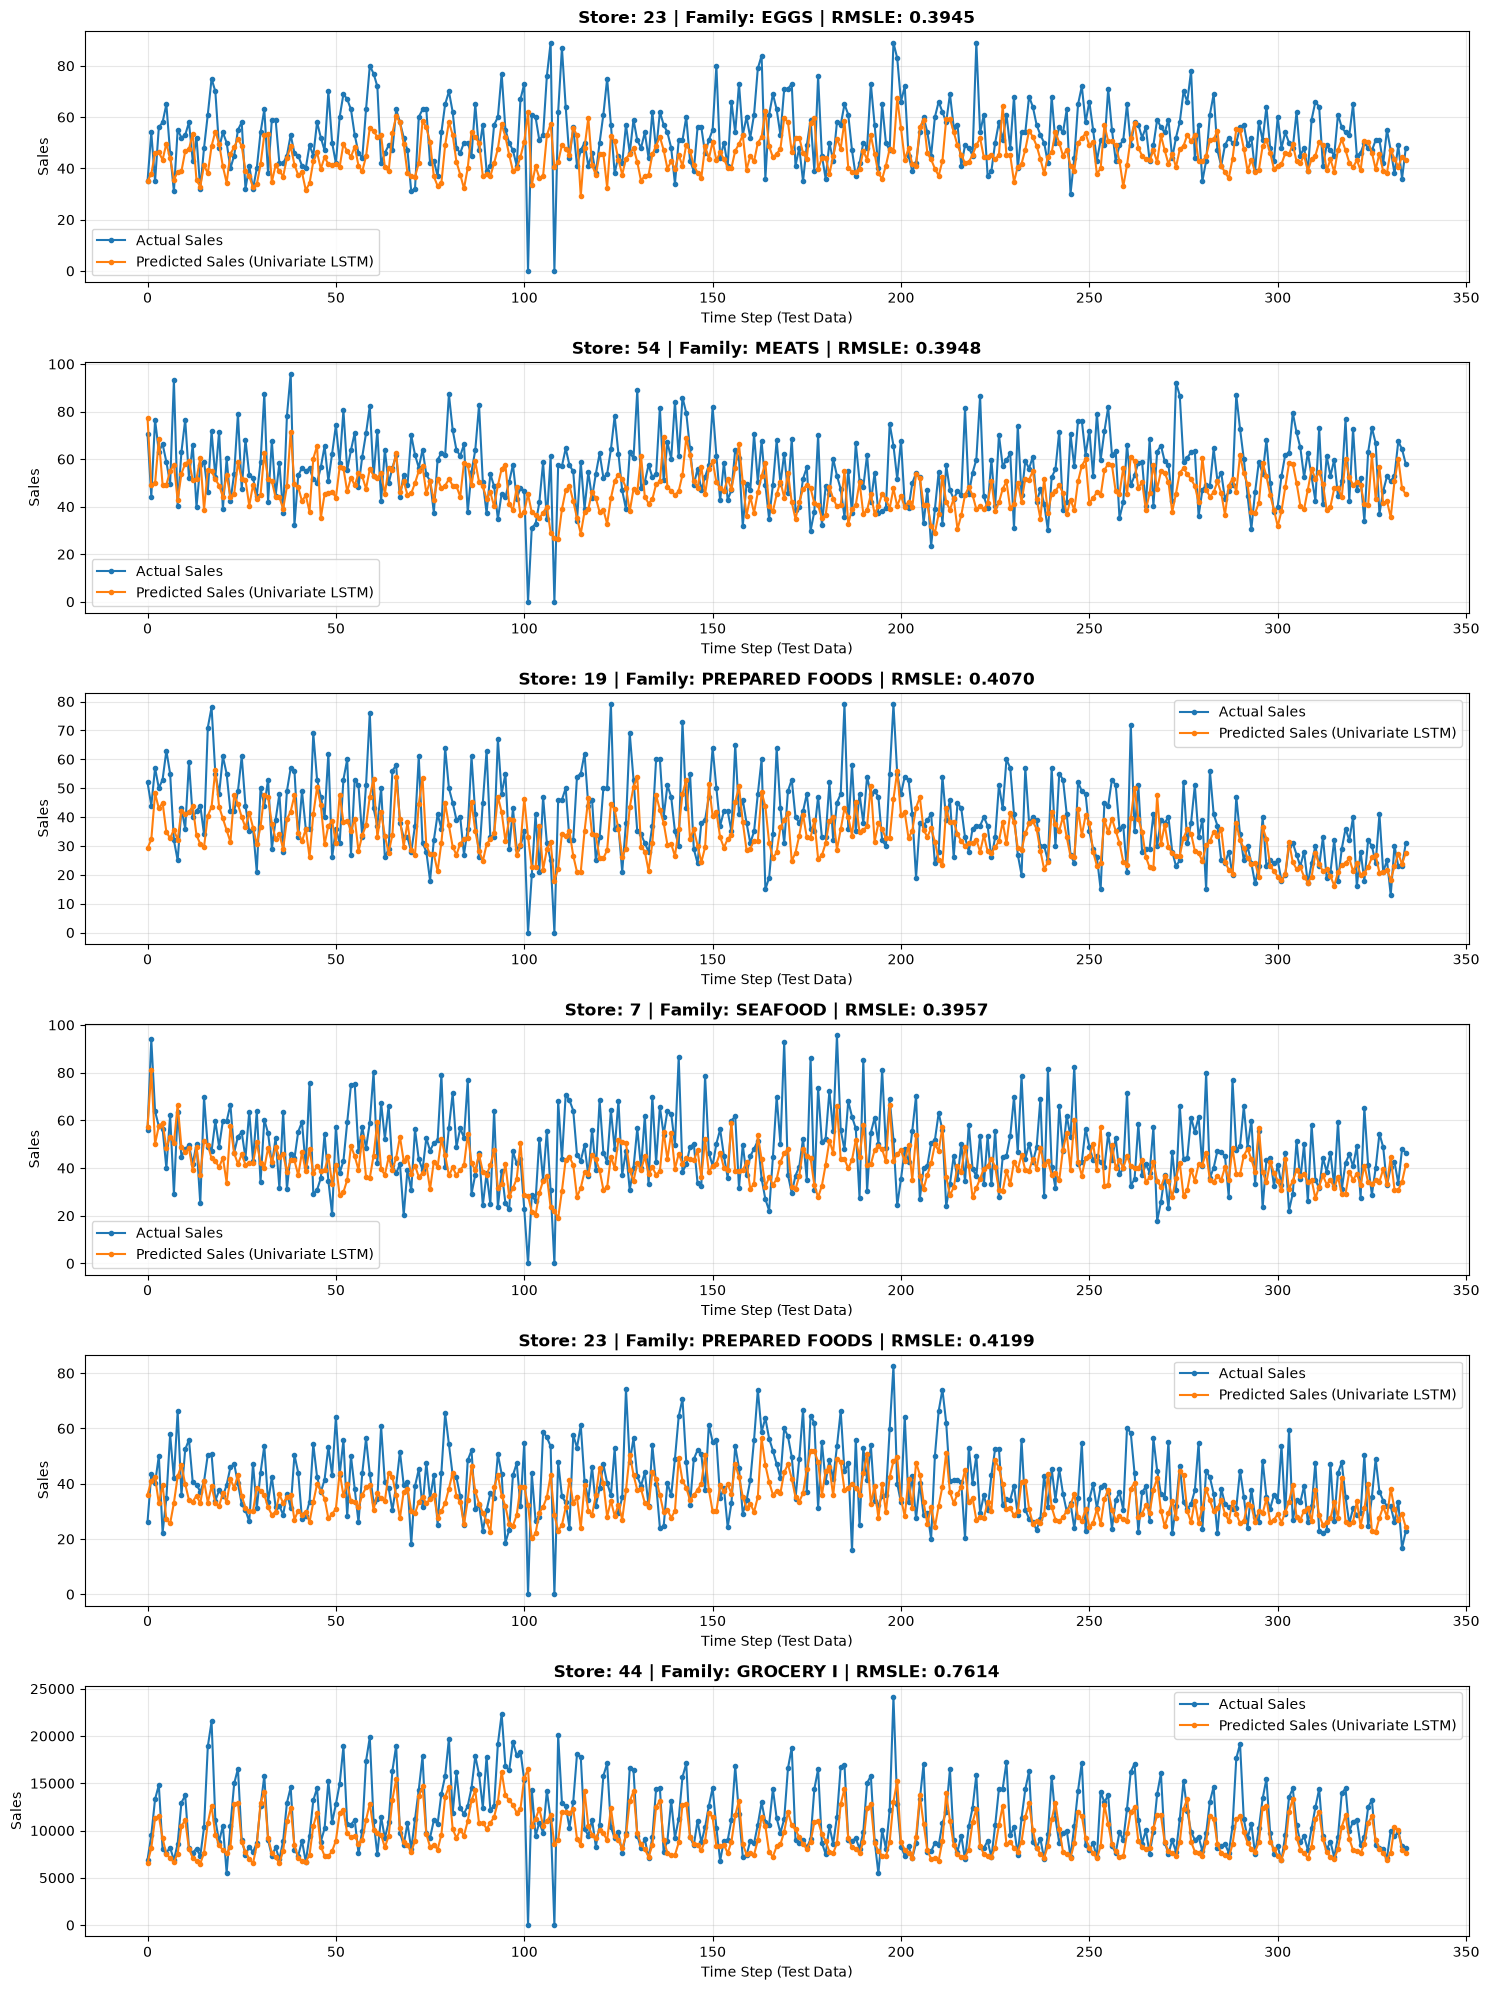

In [9]:
# 6 Kombinasi Store dan Family yang difokuskan
target_combos = [
    (23, 'EGGS'),
    (54, 'MEATS'),
    (19, 'PREPARED FOODS'),
    (7, 'SEAFOOD'),
    (23, 'PREPARED FOODS'),
    (44, 'GROCERY I')
]

# Menampilkan hasil evaluasi RMSLE untuk 6 kombinasi target
selected_rows_uv = []
for store, family in target_combos:
    row = results_df[(results_df['store_nbr'] == store) & (results_df['family'] == family)]
    if not row.empty:
        selected_rows_uv.append(row.iloc[0])

target_results_uv_df = pd.DataFrame(selected_rows_uv)
print("Hasil Evaluasi untuk 6 Kombinasi Target (Univariate LSTM):")
display(target_results_uv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 6 kombinasi target
plt.figure(figsize=(15, 20))
for i, (store, family) in enumerate(target_combos, 1):
    rmsle_val = results_df[(results_df['store_nbr'] == store) & (results_df['family'] == family)]['RMSLE'].values[0]
    y_true, y_pred = plot_data_uv[(store, family)]
    
    plt.subplot(6, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Univariate LSTM)', marker='.', color='tab:orange')
    plt.title(f'Store: {store} | Family: {family} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Eksperimen Model LSTM Univariat Dengan Model LSTM Yang Lebih Kompleks

In [10]:
# 1. Membangun Arsitektur LSTM Univariat Kompleks (2 Layer + Dropout + Dense Projection)
model_complex_uv = Sequential([
    Input(shape=(TIME_STEPS, 1)),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_complex_uv.compile(optimizer='adam', loss='mse')
model_complex_uv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 2. Pelatihan Model Global Complex Univariate LSTM
early_stop_complex_uv = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_complex_uv = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

print("Memulai pelatihan model global Complex Univariate LSTM...")
history_complex_uv = model_complex_uv.fit(
    X_train_pooled, y_train_pooled,
    validation_split=0.1,
    epochs=25,
    batch_size=256,
    callbacks=[early_stop_complex_uv, reduce_lr_complex_uv],
    verbose=1
)

Memulai pelatihan model global Complex Univariate LSTM...
Epoch 1/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 115s 35ms/step - loss: 0.0112 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 2/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 121s 41ms/step - loss: 0.0091 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 3/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 86s 29ms/step - loss: 0.0085 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 4/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 85s 29ms/step - loss: 0.0081 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 5/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - loss: 0.0080 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 6/25
2965/2966 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0079
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 195s 46ms/step - loss: 0.0079 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 7/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 103s 35ms/step - loss: 0.0078 - val_loss: 0.0085 - learning_rate: 5.0000e-04
E

In [12]:
# 3. Evaluasi per Kombinasi dan Perhitungan RMSLE (Complex Univariate)
results_complex_uv = []
plot_data_complex_uv = {}
print("Mulai proses evaluasi Complex Univariate LSTM per kombinasi...")

test_idx_set = set(test_idx)

for idx, (store, family) in enumerate(smooth_combinations.itertuples(index=False)):
    combo_test_idxs = [i for i, m in enumerate(pooled_meta) if m[0]==store and m[1]==family and i in test_idx_set]
    
    if len(combo_test_idxs) == 0:
        continue
        
    X_test_combo = pooled_X[combo_test_idxs]   
    y_test_combo_scaled = pooled_y[combo_test_idxs]
    
    y_pred_scaled = model_complex_uv.predict(X_test_combo, verbose=0)
    
    scaler = series_scalers[(store, family)]
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_combo = scaler.inverse_transform(y_test_combo_scaled.reshape(-1, 1))
    
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))
    
    results_complex_uv.append({
        'store_nbr': store,
        'family': family,
        'RMSLE': rmsle
    })
    plot_data_complex_uv[(store, family)] = (y_test_combo, y_pred)
    
    if (idx + 1) % 100 == 0:
        print(f"Selesai evaluasi {idx + 1} kombinasi...")

results_complex_uv_df = pd.DataFrame(results_complex_uv)
print("\n--- Rangkuman Evaluasi Complex Univariate Keseluruhan ---")
display(results_complex_uv_df[['RMSLE']].describe())

Mulai proses evaluasi Complex Univariate LSTM per kombinasi...
Selesai evaluasi 100 kombinasi...
Selesai evaluasi 200 kombinasi...
Selesai evaluasi 300 kombinasi...
Selesai evaluasi 400 kombinasi...
Selesai evaluasi 500 kombinasi...
Selesai evaluasi 600 kombinasi...

--- Rangkuman Evaluasi Complex Univariate Keseluruhan ---


,RMSLE
count,630.000000
mean,0.561952
std,0.280393
min,0.325064
25%,0.441254
50%,0.507828
75%,0.586365
max,3.162892


Hasil Evaluasi untuk 6 Kombinasi Target (Complex Univariate LSTM):


,store_nbr,family,RMSLE
153,23,EGGS,0.331269
560,54,MEATS,0.338872
132,19,PREPARED FOODS,0.349359
597,7,SEAFOOD,0.368337
159,23,PREPARED FOODS,0.368482
426,44,GROCERY I,0.725382


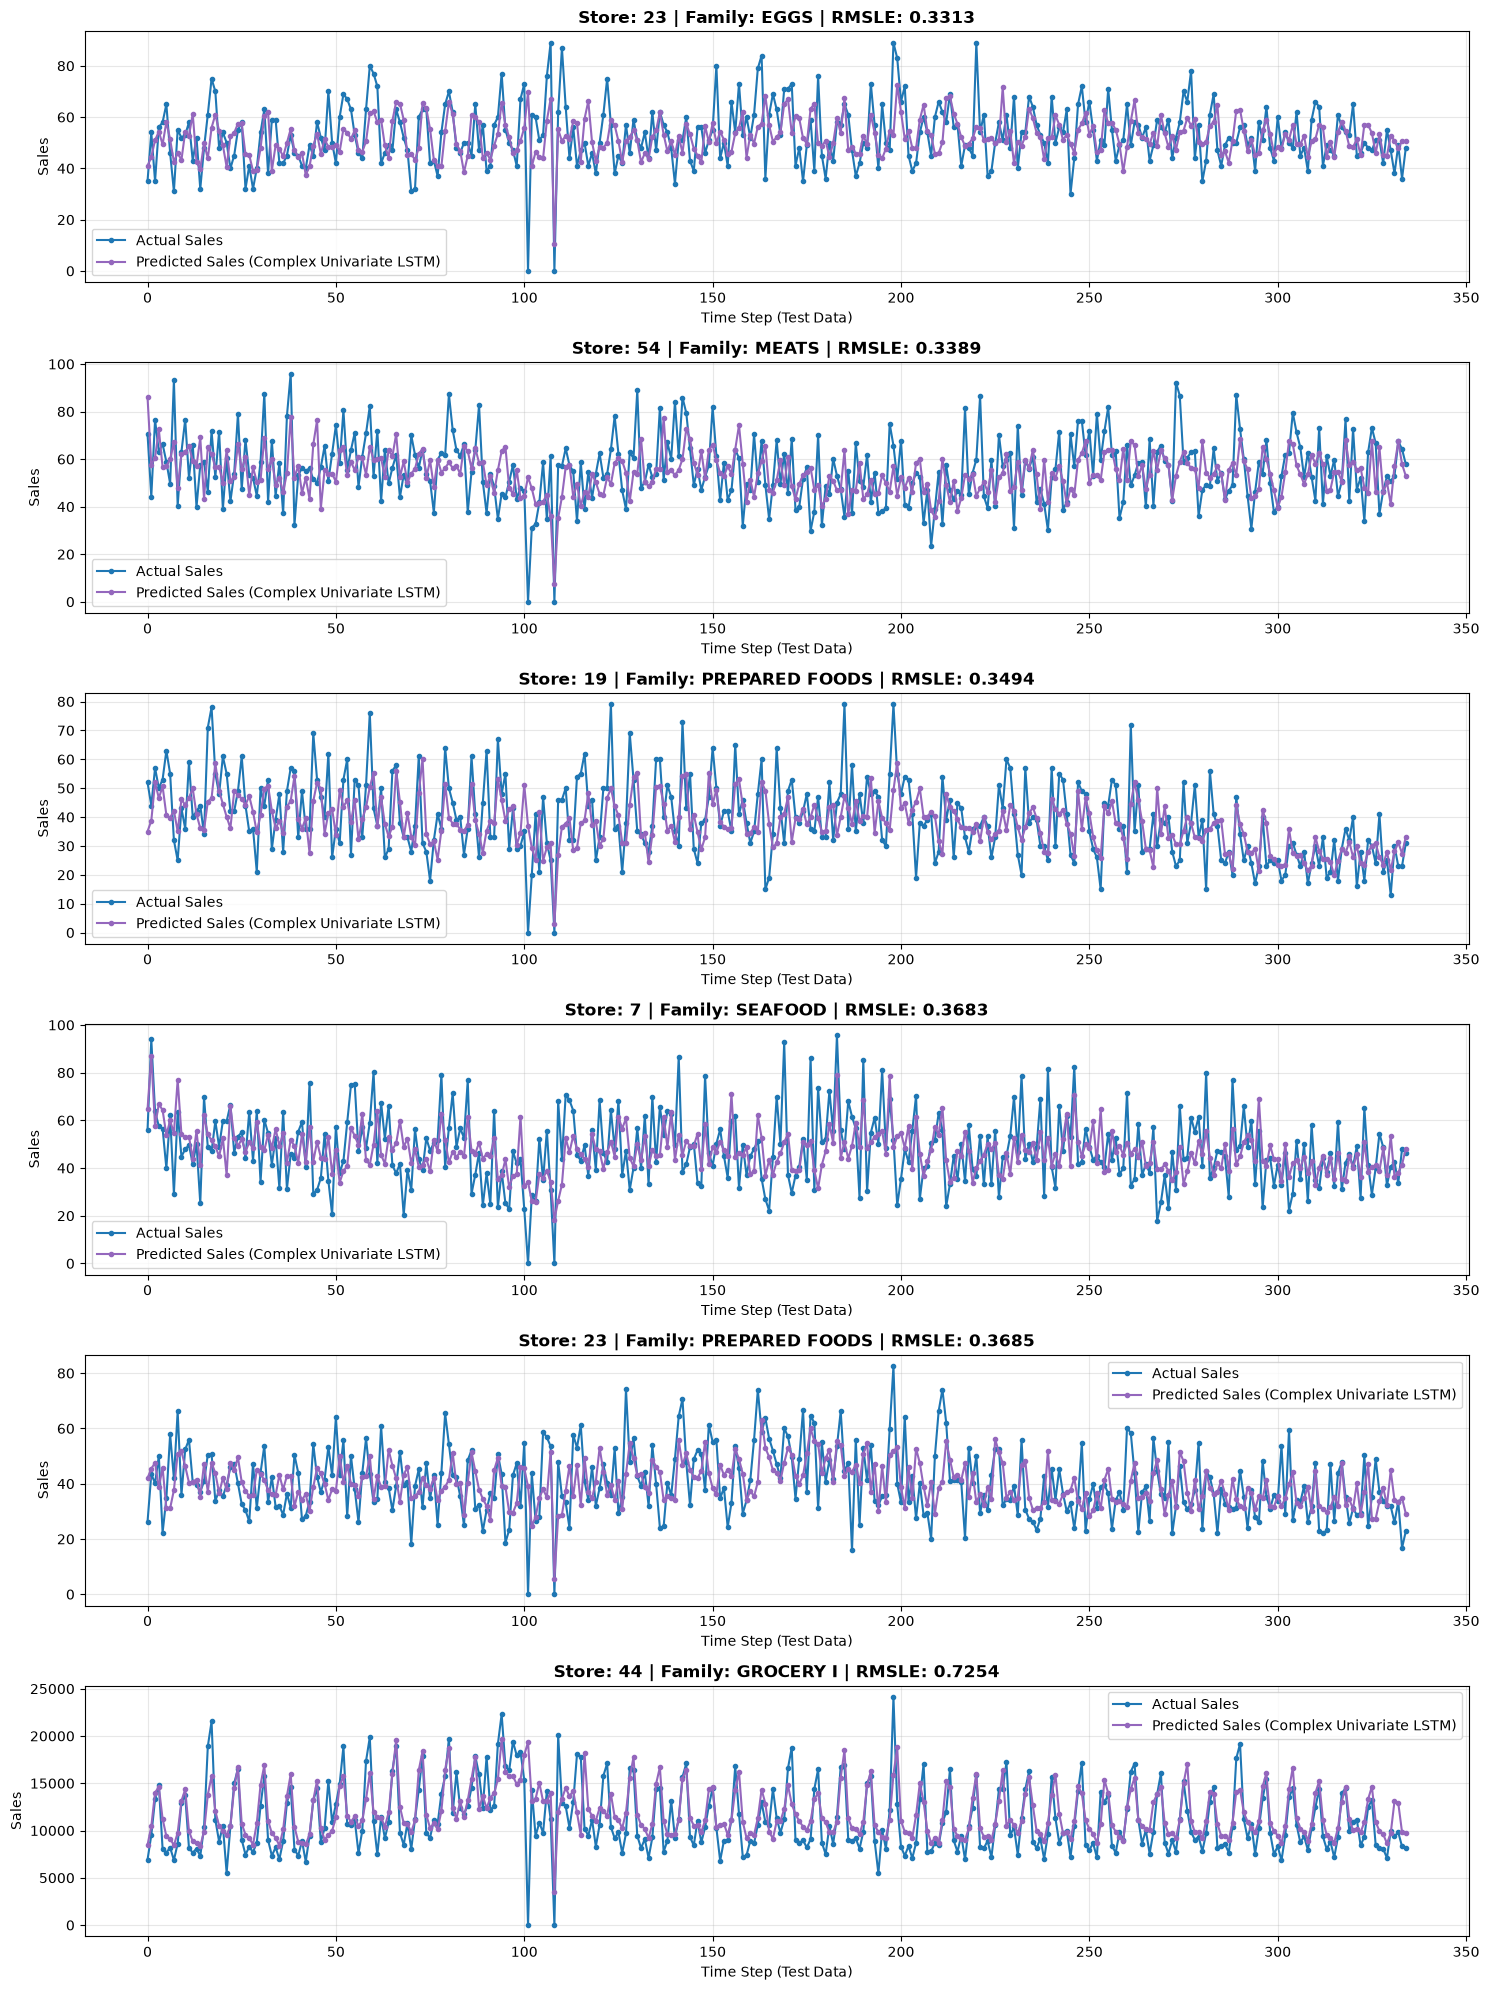

In [13]:
# 4. Visualisasi 6 Kombinasi Target (Complex Univariate LSTM)
selected_rows_complex_uv = []
for store, family in target_combos:
    row = results_complex_uv_df[(results_complex_uv_df['store_nbr'] == store) & (results_complex_uv_df['family'] == family)]
    if not row.empty:
        selected_rows_complex_uv.append(row.iloc[0])

target_results_complex_uv_df = pd.DataFrame(selected_rows_complex_uv)
print("Hasil Evaluasi untuk 6 Kombinasi Target (Complex Univariate LSTM):")
display(target_results_complex_uv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 6 kombinasi target
plt.figure(figsize=(15, 20))
for i, (store, family) in enumerate(target_combos, 1):
    rmsle_val = results_complex_uv_df[(results_complex_uv_df['store_nbr'] == store) & (results_complex_uv_df['family'] == family)]['RMSLE'].values[0]
    y_true, y_pred = plot_data_complex_uv[(store, family)]
    
    plt.subplot(6, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Complex Univariate LSTM)', marker='.', color='tab:purple')
    plt.title(f'Store: {store} | Family: {family} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 5. Komparasi Performa RMSLE: Simple Univariate vs Complex Univariate pada 6 Kombinasi Target
comparison_uv_df = pd.DataFrame({
    'Store': [s for s, f in target_combos],
    'Family': [f for s, f in target_combos],
    'RMSLE Simple Univariate': target_results_uv_df['RMSLE'].values,
    'RMSLE Complex Univariate': target_results_complex_uv_df['RMSLE'].values,
})
comparison_uv_df['Improvement (%)'] = ((comparison_uv_df['RMSLE Simple Univariate'] - comparison_uv_df['RMSLE Complex Univariate']) / comparison_uv_df['RMSLE Simple Univariate']) * 100

print("--- Tabel Komparasi RMSLE: Simple vs Complex Univariate (6 Kombinasi Target) ---")
display(comparison_uv_df)

--- Tabel Komparasi RMSLE: Simple vs Complex Univariate (6 Kombinasi Target) ---


,Store,Family,RMSLE Simple Univariate,RMSLE Complex Univariate,Improvement (%)
0,23,EGGS,0.394478,0.331269,16.023575
1,54,MEATS,0.394786,0.338872,14.163028
2,19,PREPARED FOODS,0.407003,0.349359,14.163010
3,7,SEAFOOD,0.395658,0.368337,6.905081
4,23,PREPARED FOODS,0.419881,0.368482,12.241278
5,44,GROCERY I,0.761447,0.725382,4.736391


## LSTM Multivariat

### Eksperimen Model LSTM Multivariat Dengan Model LSTM Sederhana

In [15]:
# 1. Memuat dan Memproses Data Eksternal
oil = pd.read_csv('../datasets/oil.csv', parse_dates=['date'])
holidays = pd.read_csv('../datasets/holidays_events.csv', parse_dates=['date'])
stores = pd.read_csv('../datasets/stores.csv')

# 1.1 Preprocessing Harga Minyak Mentah (WTI) dengan interpolasi linear kalender lengkap
oil_complete = pd.DataFrame({'date': pd.date_range(train['date'].min(), train['date'].max())})
oil_complete = oil_complete.merge(oil, on='date', how='left')
oil_complete['oil_price'] = oil_complete['dcoilwtico'].interpolate(method='linear').bfill().ffill()
oil_complete = oil_complete[['date', 'oil_price']]

# 1.2 Preprocessing Hari Libur Non-Transfer (Locale-Aware: National, Regional, Local)
valid_holidays = holidays[holidays['transferred'] == False].copy()
nat_h = set(valid_holidays[valid_holidays['locale'] == 'National']['date'].unique())

reg_h_map = {}
for state in stores['state'].unique():
    reg_h_map[state] = set(valid_holidays[(valid_holidays['locale'] == 'Regional') & (valid_holidays['locale_name'] == state)]['date'].unique())

loc_h_map = {}
for city in stores['city'].unique():
    loc_h_map[city] = set(valid_holidays[(valid_holidays['locale'] == 'Local') & (valid_holidays['locale_name'] == city)]['date'].unique())

# 1.3 Mapping Karakteristik Toko (Cluster, City, State)
store_lookup = stores.set_index('store_nbr')[['city', 'state', 'cluster']].to_dict('index')

# 1.4 Definisi Fitur Multivariat (Target 'sales' di indeks 0 + 10 Fitur Prediktif)
feature_cols = [
    'sales', 
    'onpromotion', 
    'promo_rolling_mean_7', 
    'oil_price', 
    'is_holiday', 
    'is_weekend', 
    'is_payday', 
    'day_sin', 
    'day_cos', 
    'sales_lag_7', 
    'cluster'
]
NUM_FEATURES = len(feature_cols)

print(f"Total {NUM_FEATURES} Fitur Multivariat yang digunakan:")
for i, col in enumerate(feature_cols):
    print(f"  {i}. {col}")

Total 11 Fitur Multivariat yang digunakan:
  0. sales
  1. onpromotion
  2. promo_rolling_mean_7
  3. oil_price
  4. is_holiday
  5. is_weekend
  6. is_payday
  7. day_sin
  8. day_cos
  9. sales_lag_7
  10. cluster


In [16]:
# 2. Pembuatan Data Sequence Multivariat (Feature Extraction, Pooling & Dual Scaling)
TIME_STEPS = 14
pooled_X_mv, pooled_y_mv, pooled_meta_mv = [], [], []
scalers_mv = {}         # Scaler untuk seluruh fitur input (X)
scalers_target_mv = {}  # Scaler khusus untuk target sales (y) untuk inverse transform presisi

print(f"Memulai ekstraksi {NUM_FEATURES} fitur untuk {len(smooth_combinations)} kombinasi 'Smooth'...")

for idx, (store, family) in enumerate(smooth_combinations.itertuples(index=False)):
    s_info = store_lookup[store]
    store_city = s_info['city']
    store_state = s_info['state']
    store_cluster = s_info['cluster']

    # Filter deret waktu kombinasi store & family
    df_sub = train[(train['store_nbr'] == store) & (train['family'] == family)].copy()
    df_sub = df_sub.groupby('date')[['sales', 'onpromotion']].sum().reset_index().set_index('date').asfreq('D').fillna(0).reset_index()

    # Gabungkan dengan harga minyak
    df_sub = df_sub.merge(oil_complete, on='date', how='left')

    # Fitur Libur Locale-Aware
    store_holidays = nat_h.union(reg_h_map.get(store_state, set())).union(loc_h_map.get(store_city, set()))
    df_sub['is_holiday'] = df_sub['date'].isin(store_holidays).astype(int)

    # Fitur Kalender, Weekend, Payday, Cyclical Encoding
    df_sub['dayofweek'] = df_sub['date'].dt.dayofweek
    df_sub['is_weekend'] = (df_sub['dayofweek'] >= 5).astype(int)
    df_sub['is_payday'] = ((df_sub['date'].dt.day == 15) | df_sub['date'].dt.is_month_end).astype(int)
    df_sub['day_sin'] = np.sin(2 * np.pi * df_sub['dayofweek'] / 7)
    df_sub['day_cos'] = np.cos(2 * np.pi * df_sub['dayofweek'] / 7)

    # Fitur Promosi Bergerak & Lag Penjualan Musiman
    df_sub['promo_rolling_mean_7'] = df_sub['onpromotion'].rolling(7, min_periods=1).mean()
    df_sub['sales_lag_7'] = df_sub['sales'].shift(7).bfill()
    df_sub['cluster'] = store_cluster

    data_values = df_sub[feature_cols].values
    if len(data_values) < TIME_STEPS + 20:
        continue

    # Normalisasi Fitur Input (X)
    scaler_feat = MinMaxScaler()
    data_scaled = scaler_feat.fit_transform(data_values)
    scalers_mv[(store, family)] = scaler_feat

    # Normalisasi Target Sales (y) secara terpisah
    scaler_tgt = MinMaxScaler()
    scaler_tgt.fit(df_sub[['sales']].values)
    scalers_target_mv[(store, family)] = scaler_tgt

    # Windowing sequence
    for i in range(len(data_scaled) - TIME_STEPS):
        pooled_X_mv.append(data_scaled[i : i + TIME_STEPS, :])
        pooled_y_mv.append(data_scaled[i + TIME_STEPS, 0]) # target adalah kolom 0 (sales)
        pooled_meta_mv.append((store, family, i))

pooled_X_mv = np.array(pooled_X_mv)
pooled_y_mv = np.array(pooled_y_mv)
print(f"Selesai! Total sequence Multivariat hasil pooling: {len(pooled_X_mv)} dengan shape {pooled_X_mv.shape}")

Memulai ekstraksi 11 fitur untuk 630 kombinasi 'Smooth'...
Selesai! Total sequence Multivariat hasil pooling: 1054620 dengan shape (1054620, 14, 11)


In [17]:
# 3. Pembagian Data Train/Test Multivariat (80% Train, 20% Test Kronologis)
train_idx_mv, test_idx_mv = [], []
for (store, family) in smooth_combinations.itertuples(index=False):
    idxs = [i for i, m in enumerate(pooled_meta_mv) if m[0]==store and m[1]==family]
    split = int(len(idxs) * 0.8)
    train_idx_mv += idxs[:split]
    test_idx_mv += idxs[split:]

X_train_mv, y_train_mv = pooled_X_mv[train_idx_mv], pooled_y_mv[train_idx_mv]
X_test_mv, y_test_mv = pooled_X_mv[test_idx_mv], pooled_y_mv[test_idx_mv]

print(f"Multivariate Train sequences: {len(X_train_mv)} | Test sequences: {len(X_test_mv)}")

Multivariate Train sequences: 843570 | Test sequences: 211050


In [18]:
# 4. Pelatihan Model Global Multivariat LSTM
model_mv = Sequential([
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    LSTM(64, activation='tanh', dropout=0.2),
    Dense(1)
])

model_mv.compile(optimizer='adam', loss='mse')
model_mv.summary()

early_stop_mv = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Memulai pelatihan model global multivariat...")
history_mv = model_mv.fit(
    X_train_mv, y_train_mv,
    validation_split=0.1,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop_mv],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

Memulai pelatihan model global multivariat...
Epoch 1/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 0.0119 - val_loss: 0.0143
Epoch 2/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 0.0095 - val_loss: 0.0120
Epoch 3/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.0089 - val_loss: 0.0108
Epoch 4/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 0.0086 - val_loss: 0.0123
Epoch 5/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 0.0084 - val_loss: 0.0133
Epoch 6/20
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.0083 - val_loss: 0.0140


In [19]:
# 5. Evaluasi per Kombinasi dan Perhitungan RMSLE (Multivariat)
results_mv = []
test_idx_set_mv = set(test_idx_mv)
plot_data_mv = {}

print("Mulai proses evaluasi model multivariat per kombinasi...")

for idx, (store, family) in enumerate(smooth_combinations.itertuples(index=False)):
    combo_test_idxs = [i for i, m in enumerate(pooled_meta_mv) if m[0]==store and m[1]==family and i in test_idx_set_mv]
    
    if len(combo_test_idxs) == 0:
        continue
        
    X_test_combo = pooled_X_mv[combo_test_idxs]   
    y_test_combo_scaled = pooled_y_mv[combo_test_idxs]
    
    # Prediksi
    y_pred_scaled = model_mv.predict(X_test_combo, verbose=0)
    
    # Inverse transform menggunakan scaler target presisi
    scaler_tgt = scalers_target_mv[(store, family)]
    y_pred = scaler_tgt.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_test_combo = scaler_tgt.inverse_transform(y_test_combo_scaled.reshape(-1, 1)).flatten()
    
    # Hitung RMSLE (Pastikan tidak ada nilai negatif)
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))
    
    results_mv.append({
        'store_nbr': store,
        'family': family,
        'RMSLE': rmsle
    })
    
    # Simpan hasil untuk plotting
    plot_data_mv[(store, family)] = (y_test_combo, y_pred)
    
    if (idx + 1) % 100 == 0:
        print(f"Selesai evaluasi {idx + 1} kombinasi...")

results_mv_df = pd.DataFrame(results_mv)
print("--- Rangkuman Evaluasi Multivariat Keseluruhan ---")
display(results_mv_df[['RMSLE']].describe())

Mulai proses evaluasi model multivariat per kombinasi...
Selesai evaluasi 100 kombinasi...
Selesai evaluasi 200 kombinasi...
Selesai evaluasi 300 kombinasi...
Selesai evaluasi 400 kombinasi...
Selesai evaluasi 500 kombinasi...
Selesai evaluasi 600 kombinasi...
--- Rangkuman Evaluasi Multivariat Keseluruhan ---


,RMSLE
count,630.000000
mean,0.623604
std,0.388802
min,0.394515
25%,0.490094
50%,0.540055
75%,0.621729
max,4.002773


Hasil Evaluasi untuk 6 Kombinasi Target (Multivariate LSTM):


,store_nbr,family,RMSLE
153,23,EGGS,0.394515
560,54,MEATS,0.397963
132,19,PREPARED FOODS,0.401831
597,7,SEAFOOD,0.395294
159,23,PREPARED FOODS,0.418702
426,44,GROCERY I,0.778623


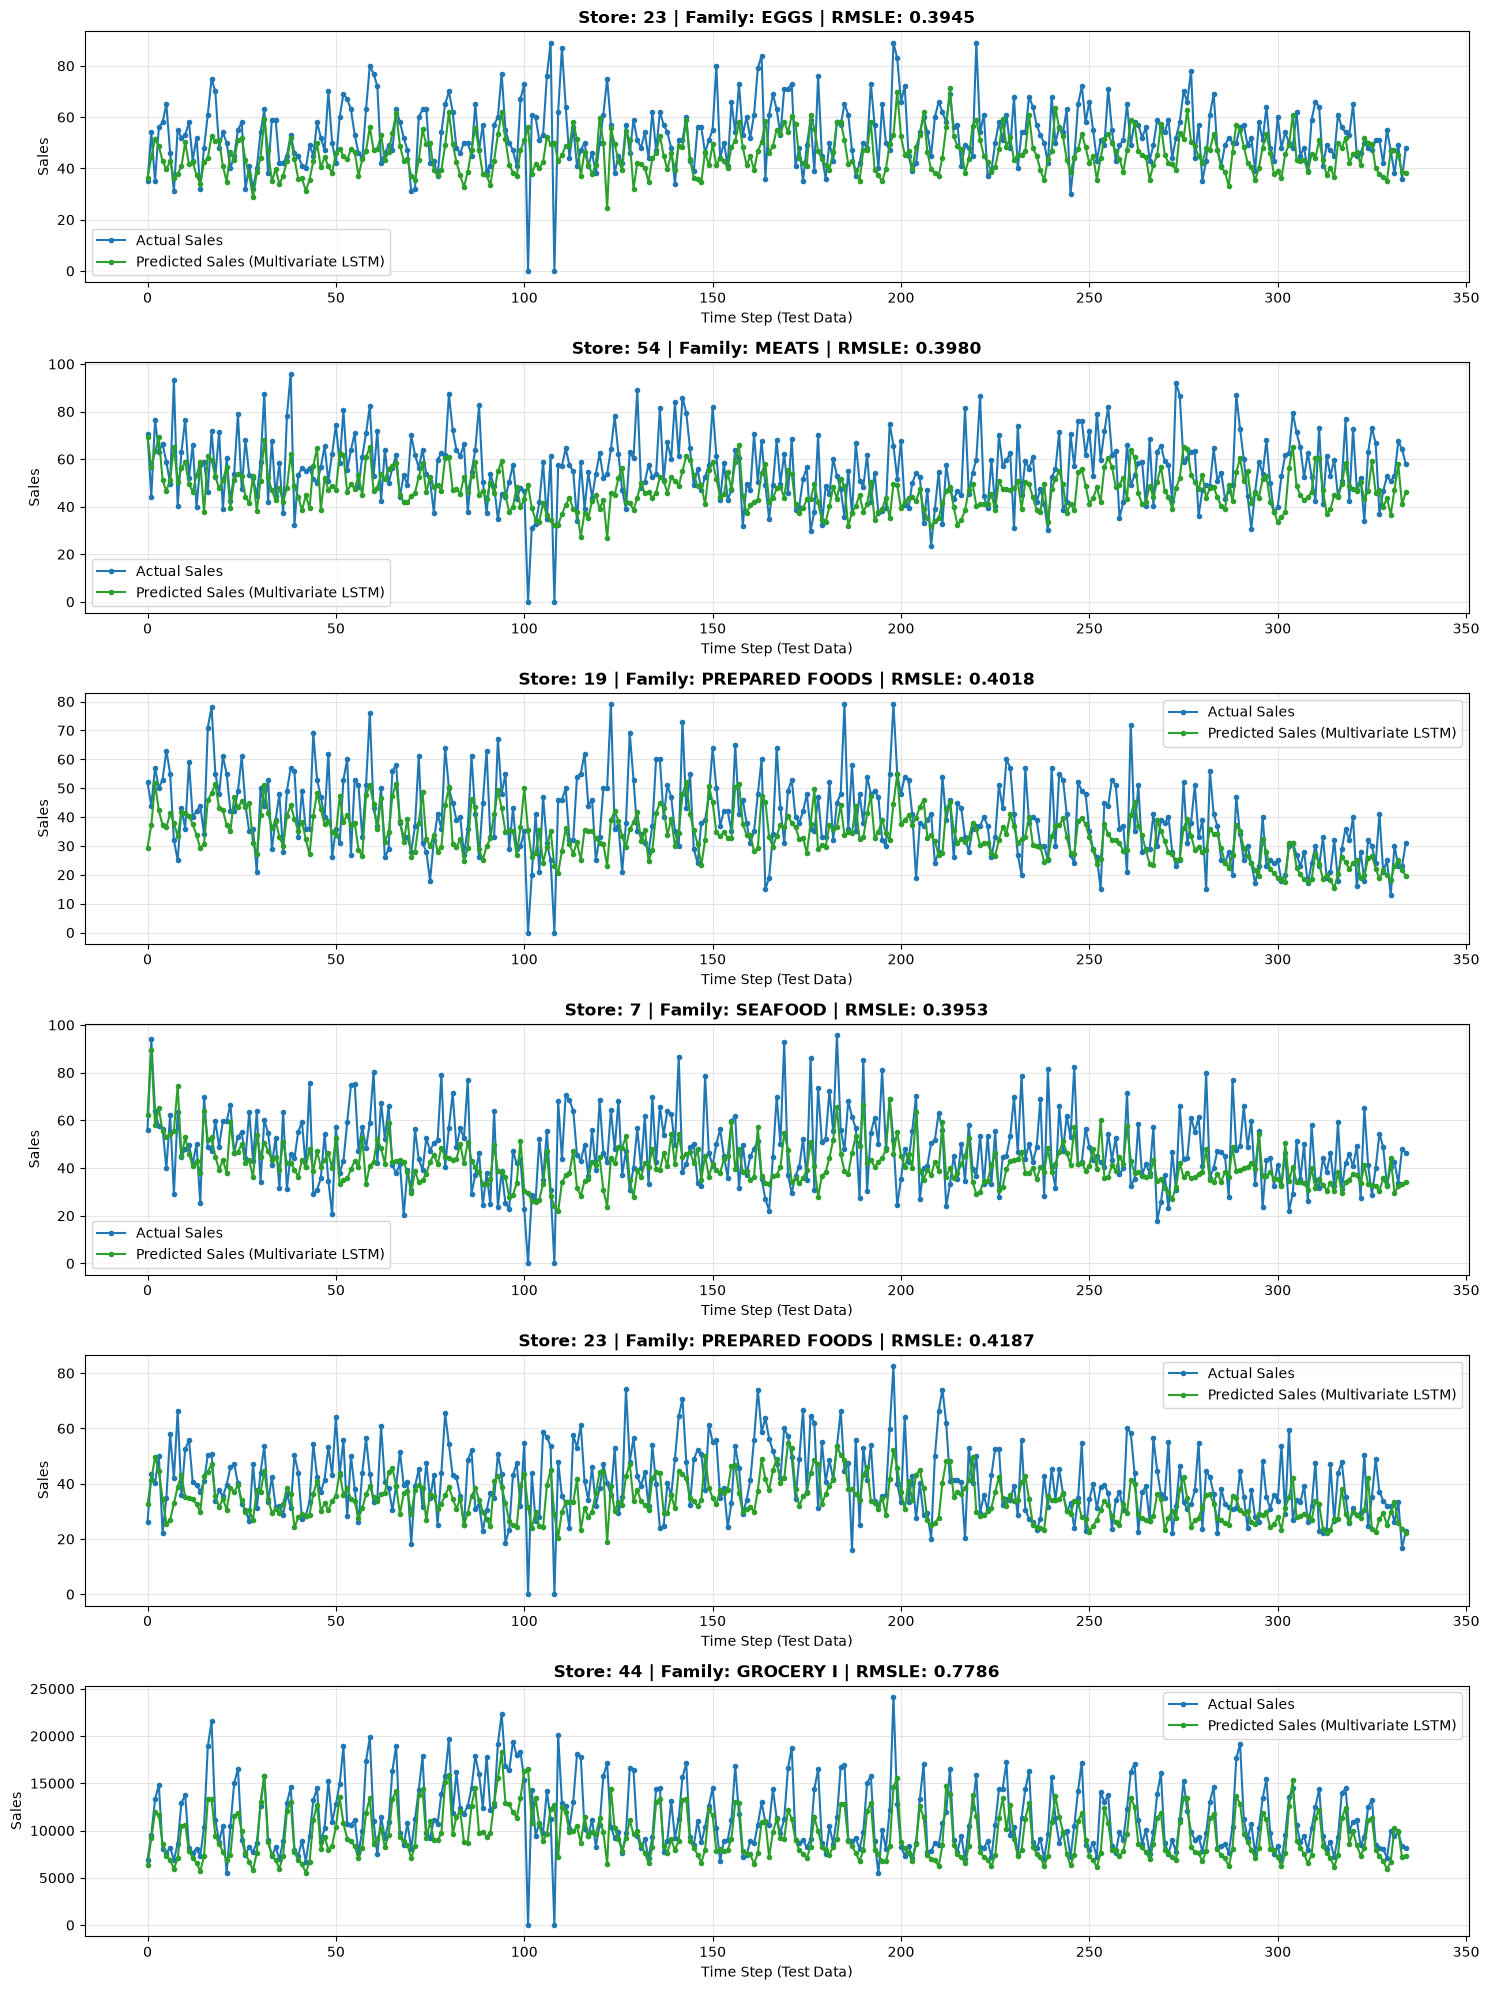

In [20]:
# 6. Visualisasi 6 Kombinasi Target (Multivariat)
selected_rows_mv = []
for store, family in target_combos:
    row = results_mv_df[(results_mv_df['store_nbr'] == store) & (results_mv_df['family'] == family)]
    if not row.empty:
        selected_rows_mv.append(row.iloc[0])

target_results_mv_df = pd.DataFrame(selected_rows_mv)
print("Hasil Evaluasi untuk 6 Kombinasi Target (Multivariate LSTM):")
display(target_results_mv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 6 kombinasi target
plt.figure(figsize=(15, 20))
for i, (store, family) in enumerate(target_combos, 1):
    rmsle_val = results_mv_df[(results_mv_df['store_nbr'] == store) & (results_mv_df['family'] == family)]['RMSLE'].values[0]
    y_true, y_pred = plot_data_mv[(store, family)]
    
    plt.subplot(6, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Multivariate LSTM)', marker='.', color='tab:green')
    plt.title(f'Store: {store} | Family: {family} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# 7. Komparasi Performa RMSLE: Univariat vs Multivariat pada 6 Kombinasi Target
comparison_df = pd.DataFrame({
    'Store': [s for s, f in target_combos],
    'Family': [f for s, f in target_combos],
    'RMSLE Univariate': target_results_uv_df['RMSLE'].values,
    'RMSLE Multivariate': target_results_mv_df['RMSLE'].values,
})
comparison_df['Improvement (%)'] = ((comparison_df['RMSLE Univariate'] - comparison_df['RMSLE Multivariate']) / comparison_df['RMSLE Univariate']) * 100

print("--- Tabel Komparasi RMSLE Univariat vs Multivariat (6 Kombinasi Target) ---")
display(comparison_df)

--- Tabel Komparasi RMSLE Univariat vs Multivariat (6 Kombinasi Target) ---


,Store,Family,RMSLE Univariate,RMSLE Multivariate,Improvement (%)
0,23,EGGS,0.394478,0.394515,-0.009374
1,54,MEATS,0.394786,0.397963,-0.804699
2,19,PREPARED FOODS,0.407003,0.401831,1.270729
3,7,SEAFOOD,0.395658,0.395294,0.091821
4,23,PREPARED FOODS,0.419881,0.418702,0.280694
5,44,GROCERY I,0.761447,0.778623,-2.255761


### Eksperimen Model LSTM Multivariat Dengan Model LSTM Yang Lebih Kompleks

In [22]:
# 1. Membangun Arsitektur LSTM Multivariat Kompleks (2 Layer + Dropout + Dense Projection)
model_complex_mv = Sequential([
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_complex_mv.compile(optimizer='adam', loss='mse')
model_complex_mv.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 14, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# 2. Pelatihan Model Global Complex Multivariate LSTM
early_stop_complex_mv = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_complex_mv = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

print("Memulai pelatihan model global Complex Multivariate LSTM...")
history_complex_mv = model_complex_mv.fit(
    X_train_mv, y_train_mv,
    validation_split=0.1,
    epochs=25,
    batch_size=256,
    callbacks=[early_stop_complex_mv, reduce_lr_complex_mv],
    verbose=1
)

Memulai pelatihan model global Complex Multivariate LSTM...
Epoch 1/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 155s 51ms/step - loss: 0.0092 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 2/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 150s 51ms/step - loss: 0.0075 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 3/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 151s 51ms/step - loss: 0.0069 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 4/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 150s 51ms/step - loss: 0.0065 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 5/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 150s 51ms/step - loss: 0.0064 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 6/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 149s 50ms/step - loss: 0.0062 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 7/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 149s 50ms/step - loss: 0.0061 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 8/25
2966/2966 ━━━━━━━━━━━━━━━━━━━━ 151s 51ms/step - loss: 0.0060 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 9/25
2966/2966

In [24]:
# 3. Evaluasi per Kombinasi dan Perhitungan RMSLE (Complex Multivariate)
results_complex_mv = []
test_idx_set_mv = set(test_idx_mv)
plot_data_complex_mv = {}

print("Mulai proses evaluasi Complex Multivariate LSTM per kombinasi...")

for idx, (store, family) in enumerate(smooth_combinations.itertuples(index=False)):
    combo_test_idxs = [i for i, m in enumerate(pooled_meta_mv) if m[0]==store and m[1]==family and i in test_idx_set_mv]
    
    if len(combo_test_idxs) == 0:
        continue
        
    X_test_combo = pooled_X_mv[combo_test_idxs]   
    y_test_combo_scaled = pooled_y_mv[combo_test_idxs]
    
    y_pred_scaled = model_complex_mv.predict(X_test_combo, verbose=0)
    
    scaler_tgt = scalers_target_mv[(store, family)]
    y_pred = scaler_tgt.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_test_combo = scaler_tgt.inverse_transform(y_test_combo_scaled.reshape(-1, 1)).flatten()
    
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))
    
    results_complex_mv.append({
        'store_nbr': store,
        'family': family,
        'RMSLE': rmsle
    })
    plot_data_complex_mv[(store, family)] = (y_test_combo, y_pred)
    
    if (idx + 1) % 100 == 0:
        print(f"Selesai evaluasi {idx + 1} kombinasi...")

results_complex_mv_df = pd.DataFrame(results_complex_mv)
print("\n--- Rangkuman Evaluasi Complex Multivariate Keseluruhan ---")
display(results_complex_mv_df[['RMSLE']].describe())

Mulai proses evaluasi Complex Multivariate LSTM per kombinasi...
Selesai evaluasi 100 kombinasi...
Selesai evaluasi 200 kombinasi...
Selesai evaluasi 300 kombinasi...
Selesai evaluasi 400 kombinasi...
Selesai evaluasi 500 kombinasi...
Selesai evaluasi 600 kombinasi...

--- Rangkuman Evaluasi Complex Multivariate Keseluruhan ---


,RMSLE
count,630.000000
mean,0.565903
std,0.247569
min,0.338561
25%,0.460489
50%,0.519482
75%,0.593789
max,2.934700


Hasil Evaluasi untuk 6 Kombinasi Target (Complex Multivariate LSTM):


,store_nbr,family,RMSLE
153,23,EGGS,0.381769
560,54,MEATS,0.338561
132,19,PREPARED FOODS,0.373930
597,7,SEAFOOD,0.348903
159,23,PREPARED FOODS,0.380519
426,44,GROCERY I,0.728799


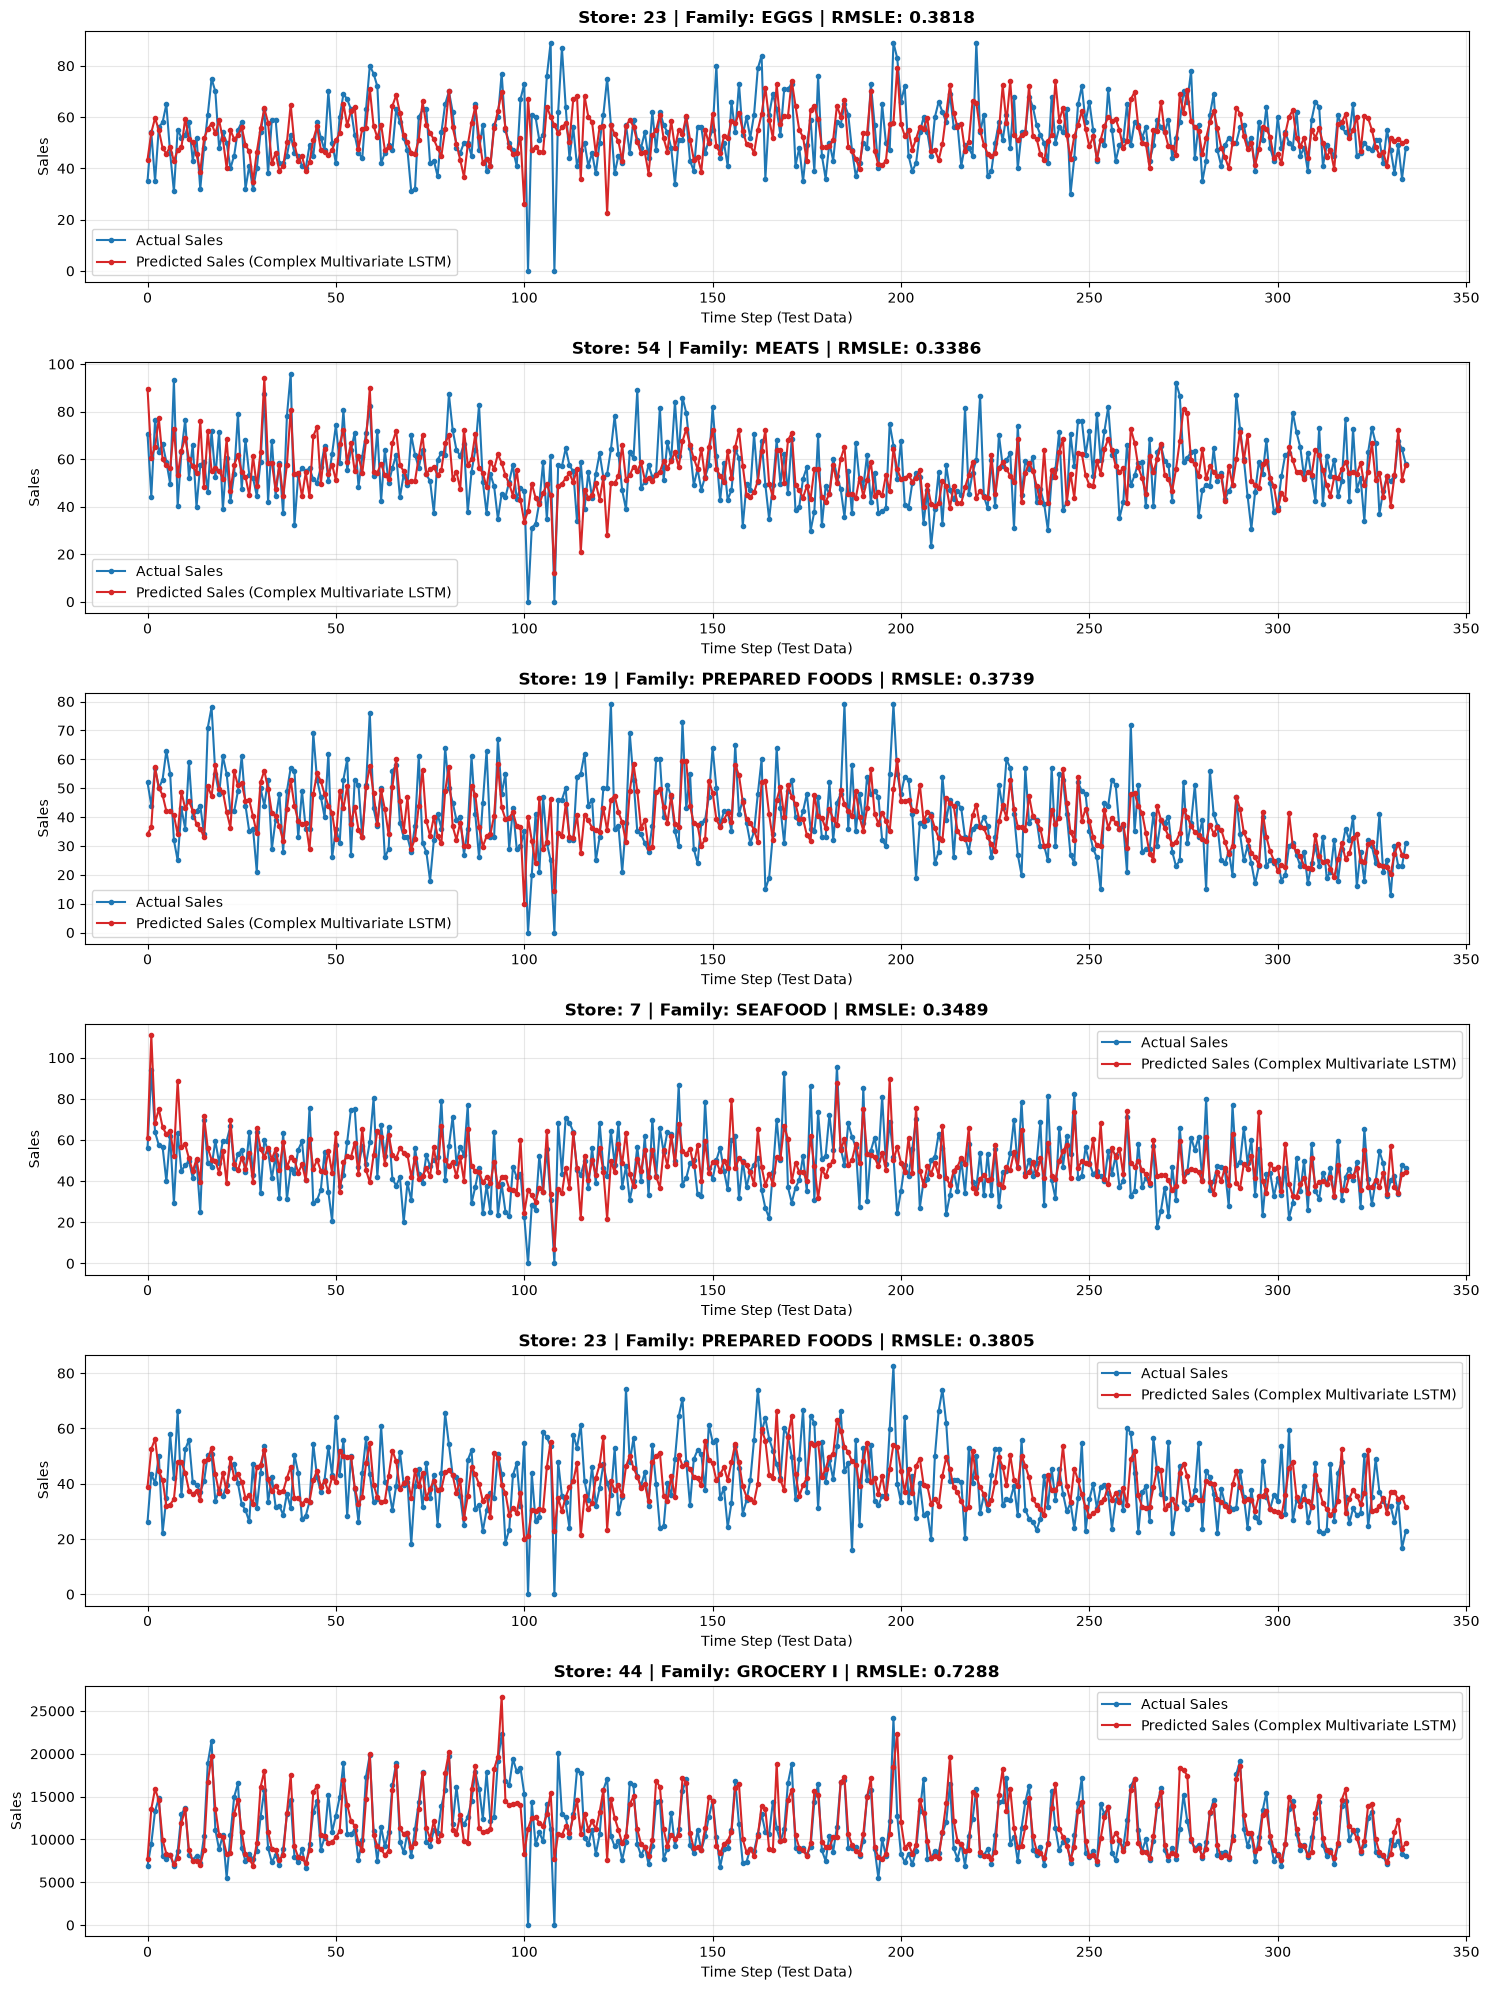

In [25]:
# 4. Visualisasi 6 Kombinasi Target (Complex Multivariate LSTM)
selected_rows_complex_mv = []
for store, family in target_combos:
    row = results_complex_mv_df[(results_complex_mv_df['store_nbr'] == store) & (results_complex_mv_df['family'] == family)]
    if not row.empty:
        selected_rows_complex_mv.append(row.iloc[0])

target_results_complex_mv_df = pd.DataFrame(selected_rows_complex_mv)
print("Hasil Evaluasi untuk 6 Kombinasi Target (Complex Multivariate LSTM):")
display(target_results_complex_mv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 6 kombinasi target
plt.figure(figsize=(15, 20))
for i, (store, family) in enumerate(target_combos, 1):
    rmsle_val = results_complex_mv_df[(results_complex_mv_df['store_nbr'] == store) & (results_complex_mv_df['family'] == family)]['RMSLE'].values[0]
    y_true, y_pred = plot_data_complex_mv[(store, family)]
    
    plt.subplot(6, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Complex Multivariate LSTM)', marker='.', color='tab:red')
    plt.title(f'Store: {store} | Family: {family} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# 5. Tabel Komparasi Menyeluruh: 4 Model Global LSTM pada 6 Kombinasi Target
summary_all_df = pd.DataFrame({
    'Store': [s for s, f in target_combos],
    'Family': [f for s, f in target_combos],
    'RMSLE Simple UV': target_results_uv_df['RMSLE'].values,
    'RMSLE Complex UV': target_results_complex_uv_df['RMSLE'].values,
    'RMSLE Simple MV': target_results_mv_df['RMSLE'].values,
    'RMSLE Complex MV': target_results_complex_mv_df['RMSLE'].values,
})
summary_all_df['Best Model'] = summary_all_df[['RMSLE Simple UV', 'RMSLE Complex UV', 'RMSLE Simple MV', 'RMSLE Complex MV']].idxmin(axis=1).str.replace('RMSLE ', '')
summary_all_df['Best RMSLE'] = summary_all_df[['RMSLE Simple UV', 'RMSLE Complex UV', 'RMSLE Simple MV', 'RMSLE Complex MV']].min(axis=1)

print("==========================================================================================")
print("          TABEL KOMPARASI AKHIR PERFORMA RMSLE: 4 MODEL GLOBAL LSTM")
print("==========================================================================================")
display(summary_all_df)

          TABEL KOMPARASI AKHIR PERFORMA RMSLE: 4 MODEL GLOBAL LSTM


,Store,Family,RMSLE Simple UV,RMSLE Complex UV,RMSLE Simple MV,RMSLE Complex MV,Best Model,Best RMSLE
0,23,EGGS,0.394478,0.331269,0.394515,0.381769,Complex UV,0.331269
1,54,MEATS,0.394786,0.338872,0.397963,0.338561,Complex MV,0.338561
2,19,PREPARED FOODS,0.407003,0.349359,0.401831,0.373930,Complex UV,0.349359
3,7,SEAFOOD,0.395658,0.368337,0.395294,0.348903,Complex MV,0.348903
4,23,PREPARED FOODS,0.419881,0.368482,0.418702,0.380519,Complex UV,0.368482
5,44,GROCERY I,0.761447,0.725382,0.778623,0.728799,Complex UV,0.725382
